C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_32152\1595365467.py:204: RuntimeWarning: Mean of empty slice
  mean_cycle = np.nanmean(Y, axis=0)
C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


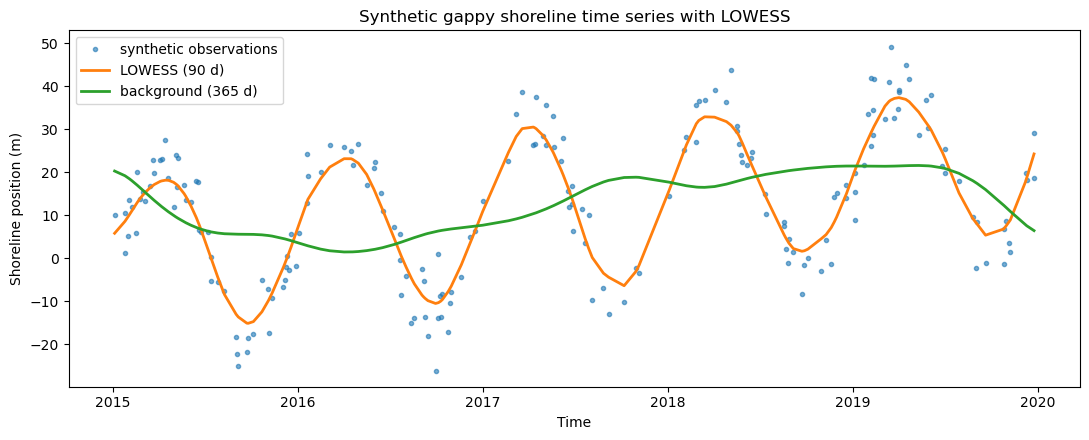

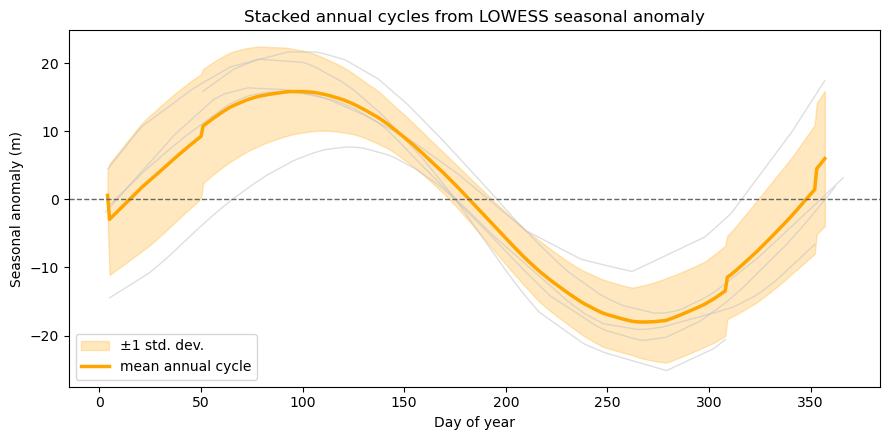

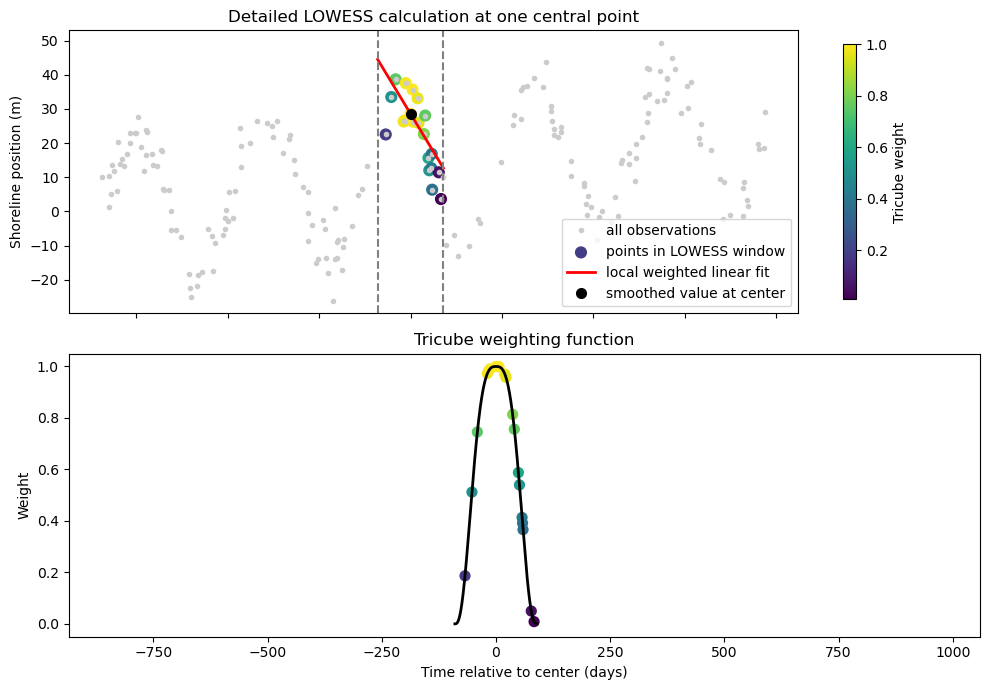

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# LOWESS with fixed time window
# ------------------------------------------------------------
def loess_time_window(t_days, y, window_days=90, min_points=5):
    """
    Time-windowed LOWESS using tricube weights and local linear regression.

    Parameters
    ----------
    t_days : array-like
        Time in days.
    y : array-like
        Data values.
    window_days : float
        Half-width of time window in days.
    min_points : int
        Minimum number of valid points required.

    Returns
    -------
    yhat : ndarray
        LOWESS-smoothed values.
    npts : ndarray
        Number of points used in each local fit.
    """
    t = np.asarray(t_days, dtype=float)
    y = np.asarray(y, dtype=float)

    yhat = np.full_like(y, np.nan, dtype=float)
    npts = np.zeros_like(y, dtype=int)

    for j, t0 in enumerate(t):
        dt = np.abs(t - t0)
        mask = np.isfinite(dt) & np.isfinite(y) & (dt <= window_days)

        if np.sum(mask) < min_points:
            continue

        tj = t[mask]
        yj = y[mask]

        # tricube weights
        w = (1 - (dt[mask] / window_days) ** 3) ** 3

        # weighted linear regression centered at t0
        X = np.vstack([np.ones_like(tj), tj - t0]).T
        WX = X * w[:, None]
        beta = np.linalg.pinv(X.T @ WX) @ (X.T @ (w * yj))

        yhat[j] = beta[0]
        npts[j] = np.sum(mask)

    return yhat, npts


def loess_single_fit(t_days, y, t0, window_days=90, min_points=5):
    """
    Compute one local LOWESS fit centered at t0 and return details.
    """
    t = np.asarray(t_days, dtype=float)
    y = np.asarray(y, dtype=float)

    dt = np.abs(t - t0)
    mask = np.isfinite(dt) & np.isfinite(y) & (dt <= window_days)

    if np.sum(mask) < min_points:
        return None

    tj = t[mask]
    yj = y[mask]
    w = (1 - (dt[mask] / window_days) ** 3) ** 3

    X = np.vstack([np.ones_like(tj), tj - t0]).T
    WX = X * w[:, None]
    beta = np.linalg.pinv(X.T @ WX) @ (X.T @ (w * yj))

    yhat0 = beta[0]
    slope = beta[1]

    return {
        "t0": t0,
        "tj": tj,
        "yj": yj,
        "w": w,
        "beta0": yhat0,
        "beta1": slope,
        "mask": mask,
    }


# ------------------------------------------------------------
# Synthetic shoreline data
# ------------------------------------------------------------
def make_gappy_shoreline_data(
    start="2015-01-01",
    nyears=5,
    n_per_month=3,
    annual_amp=20.0,
    noise_std=5.0,
    trend_m_per_year=5.0,
    seed=42,
):
    """
    Make synthetic gappy shoreline data with irregular sample times.
    """
    rng = np.random.default_rng(seed)

    start = pd.Timestamp(start)
    end = start + pd.DateOffset(years=nyears)

    months = pd.date_range(start, end, freq="MS", inclusive="left")
    times = []

    for m0 in months:
        m1 = m0 + pd.offsets.MonthBegin(1)
        ndays = (m1 - m0).days

        # Poisson count around desired average
        k = rng.poisson(n_per_month)

        # allow some empty months, but keep some data overall
        if k == 0:
            continue

        day_offsets = rng.uniform(0, ndays, size=k)
        for d in day_offsets:
            times.append(m0 + pd.to_timedelta(d, unit="D"))

    times = pd.to_datetime(sorted(times))
    df = pd.DataFrame({"datetime": times})

    # time in years since start
    t_days = (df["datetime"] - start).dt.total_seconds() / 86400.0
    t_years = t_days / 365.25

    # annual sinusoid + trend + noise
    annual = annual_amp * np.sin(2 * np.pi * t_years)
    trend = trend_m_per_year * t_years
    noise = rng.normal(0.0, noise_std, size=len(df))

    df["t_days"] = t_days
    df["t_years"] = t_years
    df["annual_true"] = annual
    df["trend_true"] = trend
    df["noise"] = noise
    df["shoreline"] = annual + trend + noise

    return df


# ------------------------------------------------------------
# Annual-cycle stacking
# ------------------------------------------------------------
def stack_annual_cycles(time, y, min_points_per_year=6, ndoy=366):
    """
    Stack yearly curves onto a common day-of-year axis and compute mean/std.
    """
    df = pd.DataFrame({"datetime": pd.to_datetime(time), "y": y}).dropna()
    df["year"] = df["datetime"].dt.year
    df["doy"] = (
        df["datetime"].dt.dayofyear
        + df["datetime"].dt.hour / 24.0
        + df["datetime"].dt.minute / 1440.0
        + df["datetime"].dt.second / 86400.0
    )

    doy_grid = np.linspace(1, 366, ndoy)
    curves = []
    years_used = []

    for yr, g in df.groupby("year"):
        g = g.sort_values("doy")

        x = g["doy"].to_numpy(dtype=float)
        yy = g["y"].to_numpy(dtype=float)

        if len(x) < min_points_per_year:
            continue

        tmp = pd.DataFrame({"doy": x, "y": yy}).groupby("doy", as_index=False).mean()
        x = tmp["doy"].to_numpy(dtype=float)
        yy = tmp["y"].to_numpy(dtype=float)

        if len(x) < 2:
            continue

        yi = np.interp(doy_grid, x, yy, left=np.nan, right=np.nan)
        inside = (doy_grid >= x.min()) & (doy_grid <= x.max())
        yi[~inside] = np.nan

        curves.append(yi)
        years_used.append(yr)

    if len(curves) == 0:
        raise ValueError("No annual curves could be constructed.")

    Y = np.vstack(curves)
    n_contrib = np.sum(np.isfinite(Y), axis=0)
    mean_cycle = np.nanmean(Y, axis=0)
    std_cycle = np.nanstd(Y, axis=0, ddof=1) if Y.shape[0] > 1 else np.full(ndoy, np.nan)

    return doy_grid, Y, np.array(years_used), mean_cycle, std_cycle, n_contrib


# ------------------------------------------------------------
# Run example
# ------------------------------------------------------------
if __name__ == "__main__":
    # parameters
    N_PER_MONTH = 3
    ANNUAL_AMP = 20.0
    NOISE_STD = 5.0
    TREND = 5.0
    WINDOW_DAYS = 90
    MIN_POINTS = 5

    # make synthetic data
    df = make_gappy_shoreline_data(
        nyears=5,
        n_per_month=N_PER_MONTH,
        annual_amp=ANNUAL_AMP,
        noise_std=NOISE_STD,
        trend_m_per_year=TREND,
        seed=42,
    )

    # LOWESS
    y_loess, npts = loess_time_window(
        df["t_days"].to_numpy(),
        df["shoreline"].to_numpy(),
        window_days=WINDOW_DAYS,
        min_points=MIN_POINTS,
    )

    df["y_loess"] = y_loess
    df["npts_loess"] = npts

    # remove long-term trend approximately using a second, longer LOWESS
    y_annual_bg, _ = loess_time_window(
        df["t_days"].to_numpy(),
        df["shoreline"].to_numpy(),
        window_days=365,
        min_points=8,
    )
    df["y_background"] = y_annual_bg
    df["seasonal_anomaly"] = df["y_loess"] - df["y_background"]

    # annual-cycle stack
    doy_grid, Y, years_used, mean_cycle, std_cycle, n_contrib = stack_annual_cycles(
        df["datetime"],
        df["seasonal_anomaly"],
        min_points_per_year=6,
        ndoy=366,
    )

    # choose one central point for detailed fit illustration
    valid = np.where(np.isfinite(df["y_loess"]))[0]
    j0 = valid[len(valid) // 2]
    fit = loess_single_fit(
        df["t_days"].to_numpy(),
        df["shoreline"].to_numpy(),
        df["t_days"].iloc[j0],
        window_days=WINDOW_DAYS,
        min_points=MIN_POINTS,
    )

    # --------------------------------------------------------
    # Plot 1: full time series
    # --------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(11, 4.5))
    ax1.plot(df["datetime"], df["shoreline"], ".", label="synthetic observations", alpha=0.6)
    ax1.plot(df["datetime"], df["y_loess"], "-", lw=2, label=f"LOWESS ({WINDOW_DAYS} d)")
    ax1.plot(df["datetime"], df["y_background"], "-", lw=2, label="background (365 d)")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Shoreline position (m)")
    ax1.set_title("Synthetic gappy shoreline time series with LOWESS")
    ax1.legend()
    fig1.tight_layout()

    # --------------------------------------------------------
    # Plot 2: average annual cycle
    # --------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(9, 4.5))
    for i in range(Y.shape[0]):
        ax2.plot(doy_grid, Y[i, :], "-", color="0.75", alpha=0.5, lw=1)

    mask = n_contrib >= 3
    mean_plot = mean_cycle.copy()
    std_plot = std_cycle.copy()
    mean_plot[~mask] = np.nan
    std_plot[~mask] = np.nan

    ax2.fill_between(
        doy_grid,
        mean_plot - std_plot,
        mean_plot + std_plot,
        color="orange",
        alpha=0.25,
        label="±1 std. dev."
    )
    ax2.plot(doy_grid, mean_plot, "-", color="orange", lw=2.5, label="mean annual cycle")
    ax2.axhline(0, color="0.4", ls="--", lw=1)

    ax2.set_xlabel("Day of year")
    ax2.set_ylabel("Seasonal anomaly (m)")
    ax2.set_title("Stacked annual cycles from LOWESS seasonal anomaly")
    ax2.legend()
    fig2.tight_layout()

    # --------------------------------------------------------
    # Plot 3: detailed local fit around one central point
    # --------------------------------------------------------
    fig3, (ax3a, ax3b) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    # top: local neighborhood in time
    t0 = fit["t0"]
    dt_local = fit["tj"] - t0
    y_local = fit["yj"]
    w_local = fit["w"]
    beta0 = fit["beta0"]
    beta1 = fit["beta1"]

    # all data in a broader view around t0
    dt_all = df["t_days"].to_numpy() - t0
    y_all = df["shoreline"].to_numpy()

    ax3a.plot(dt_all, y_all, ".", color="0.8", label="all observations")
    sc = ax3a.scatter(dt_local, y_local, c=w_local, s=60, label="points in LOWESS window")
    xline = np.linspace(-WINDOW_DAYS, WINDOW_DAYS, 200)
    yline = beta0 + beta1 * xline
    ax3a.plot(xline, yline, "r-", lw=2, label="local weighted linear fit")
    ax3a.plot(0, beta0, "ko", ms=7, label="smoothed value at center")
    ax3a.axvline(-WINDOW_DAYS, color="0.5", ls="--")
    ax3a.axvline(WINDOW_DAYS, color="0.5", ls="--")
    ax3a.set_ylabel("Shoreline position (m)")
    ax3a.set_title("Detailed LOWESS calculation at one central point")
    ax3a.legend(loc="best")
    cb = fig3.colorbar(sc, ax=ax3a, shrink=0.9)
    cb.set_label("Tricube weight")

    # bottom: weight function in local coordinates
    xx = np.linspace(-WINDOW_DAYS, WINDOW_DAYS, 400)
    ww = (1 - (np.abs(xx) / WINDOW_DAYS) ** 3) ** 3
    ax3b.plot(xx, ww, "k-", lw=2)
    ax3b.scatter(dt_local, w_local, c=w_local, s=50)
    ax3b.set_xlabel("Time relative to center (days)")
    ax3b.set_ylabel("Weight")
    ax3b.set_title("Tricube weighting function")

    fig3.tight_layout()
    plt.show()